Total data points: 16181661
Time range: 0.000 ms to 75.000 ms


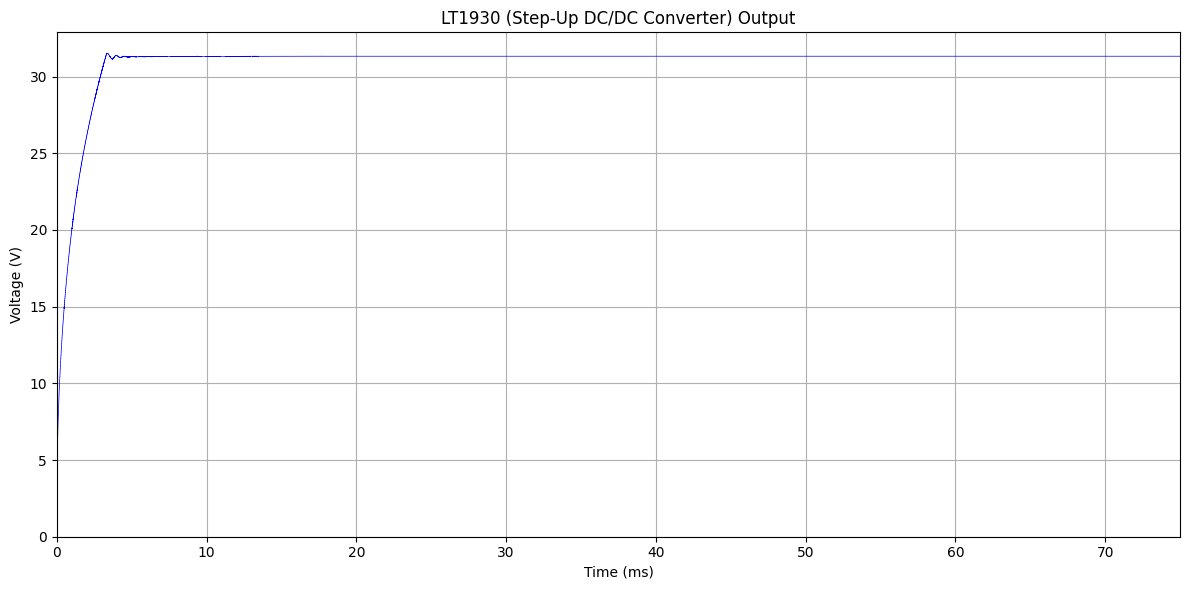

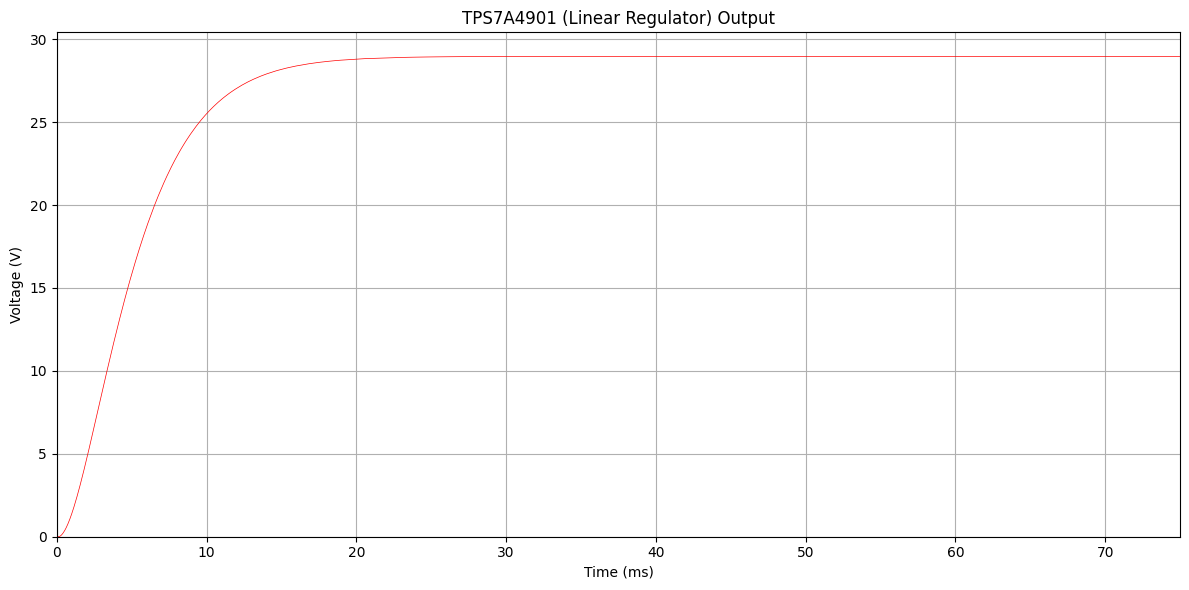

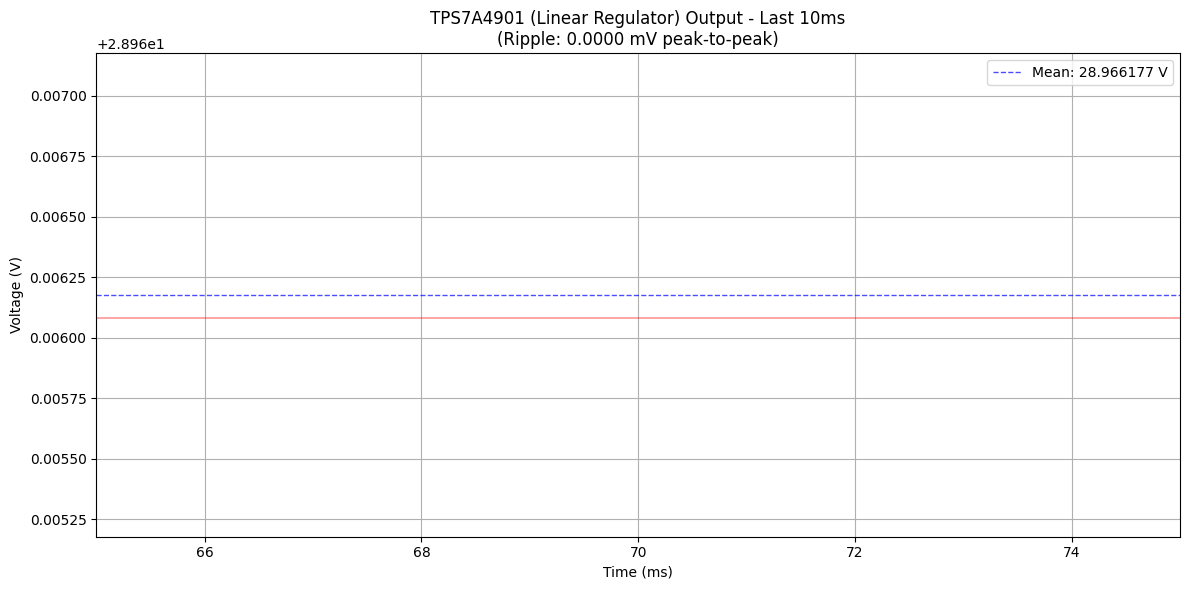


Plot 3 Y-axis scaling:
  Data range: 28.966082 V to 28.966082 V
  Variation:  0.0000 mV
  Y-axis:     28.965178 V to 28.967176 V

LT1930 (Step-Up DC/DC Converter) Analysis

Voltage:
  Minimum:  4.2460 V
  Maximum:  31.5243 V
  Mean:     31.1078 V
  Std Dev:  1736.9666 mV

Steady-State (last 25%):
  Mean:       31.3311 V
  Ripple (pp): 0.4425 mV
  Std Dev:    0.0675 mV

TPS7A4901 (Linear Regulator) Analysis

Voltage:
  Minimum:  -0.0078 V
  Maximum:  28.9661 V
  Mean:     27.6893 V
  Std Dev:  4556.1465 mV

Steady-State (last 25%):
  Mean:       28.9660 V
  Ripple (pp): 0.0000 mV
  Std Dev:    0.0515 mV

Last 10ms:
  Mean:       28.9662 V
  Minimum:    28.9661 V
  Maximum:    28.9661 V
  Ripple (pp): 0.0000 mV
  Std Dev:    0.0954 mV


In [5]:
import ltspice
import matplotlib.pyplot as plt
import numpy as np

raw = ltspice.Ltspice('/workspace/Simulation/LTspice/Schematics/InitialSensorBias.raw')
raw.parse()

# Output directory
output_dir = '/workspace/Simulation/JupyterLab/Outputs/'

# Extract data (NO downsampling)
time = raw.get_time() * 1000  # Convert to ms
v_ldo = raw.get_data('V(LDO_OUT)')
v_dcdc = raw.get_data('V(DC_DC_OUT)')

print(f"Total data points: {len(time)}")
print(f"Time range: {time[0]:.3f} ms to {time[-1]:.3f} ms")

# ============================================
# PLOT 1: DC-DC Converter Output (Full)
# ============================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(time, v_dcdc, 'b', linewidth=0.5)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('LT1930 (Step-Up DC/DC Converter) Output')
ax1.set_xlim(0, time.max())
ax1.set_ylim(0, None)
ax1.grid(True)

plt.tight_layout()
plt.savefig(output_dir + 'DcDcOutput.png', dpi=300)
plt.show()

# ============================================
# PLOT 2: Linear Regulator Output (Full)
# ============================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.plot(time, v_ldo, 'r', linewidth=0.5)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('TPS7A4901 (Linear Regulator) Output')
ax2.set_xlim(0, time.max())
ax2.set_ylim(0, None)
ax2.grid(True)

plt.tight_layout()
plt.savefig(output_dir + 'LinearRegulatorOutputFull.png', dpi=300)
plt.show()

# ============================================
# PLOT 3: Linear Regulator Output (Last 10ms) - IMPROVED SCALING
# ============================================
last_10ms_mask = time >= (time.max() - 10)
time_last = time[last_10ms_mask]
v_ldo_last = v_ldo[last_10ms_mask]

# Calculate appropriate y-axis limits to show small variations
v_mean = np.mean(v_ldo_last)
v_min = np.min(v_ldo_last)
v_max = np.max(v_ldo_last)
v_range = v_max - v_min

# Add padding (at least 10x the range, or minimum ±1mV if range is tiny)
padding = max(v_range * 5, 0.001)  # 5x range or 1mV minimum
y_lower = v_mean - padding
y_upper = v_mean + padding

fig3, ax3 = plt.subplots(figsize=(12, 6))

ax3.plot(time_last, v_ldo_last, 'r', linewidth=0.5)
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Voltage (V)')
ax3.set_title(f'TPS7A4901 (Linear Regulator) Output - Last 10ms\n(Ripple: {v_range*1000:.4f} mV peak-to-peak)')
ax3.set_xlim(time_last.min(), time_last.max())
ax3.set_ylim(y_lower, y_upper)  # <-- KEY FIX: Zoom in on the variations
ax3.grid(True)

# Add horizontal line at mean for reference
ax3.axhline(y=v_mean, color='blue', linestyle='--', linewidth=1, alpha=0.7, label=f'Mean: {v_mean:.6f} V')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig(output_dir + 'LinearRegulatorOutputLast10ms.png', dpi=300)
plt.show()

# Print the actual range for debugging
print(f"\nPlot 3 Y-axis scaling:")
print(f"  Data range: {v_min:.6f} V to {v_max:.6f} V")
print(f"  Variation:  {v_range*1000:.4f} mV")
print(f"  Y-axis:     {y_lower:.6f} V to {y_upper:.6f} V")

# ============================================
# STATISTICAL ANALYSIS
# ============================================
print("\n" + "=" * 60)
print("LT1930 (Step-Up DC/DC Converter) Analysis")
print("=" * 60)

print(f"\nVoltage:")
print(f"  Minimum:  {np.min(v_dcdc):.4f} V")
print(f"  Maximum:  {np.max(v_dcdc):.4f} V")
print(f"  Mean:     {np.mean(v_dcdc):.4f} V")
print(f"  Std Dev:  {np.std(v_dcdc)*1000:.4f} mV")

# Steady-state (last 25%)
steady_idx = int(0.75 * len(v_dcdc))
v_dcdc_steady = v_dcdc[steady_idx:]

print(f"\nSteady-State (last 25%):")
print(f"  Mean:       {np.mean(v_dcdc_steady):.4f} V")
print(f"  Ripple (pp): {(np.max(v_dcdc_steady) - np.min(v_dcdc_steady))*1000:.4f} mV")
print(f"  Std Dev:    {np.std(v_dcdc_steady)*1000:.4f} mV")

print("\n" + "=" * 60)
print("TPS7A4901 (Linear Regulator) Analysis")
print("=" * 60)

print(f"\nVoltage:")
print(f"  Minimum:  {np.min(v_ldo):.4f} V")
print(f"  Maximum:  {np.max(v_ldo):.4f} V")
print(f"  Mean:     {np.mean(v_ldo):.4f} V")
print(f"  Std Dev:  {np.std(v_ldo)*1000:.4f} mV")

# Steady-state (last 25%)
v_ldo_steady = v_ldo[steady_idx:]

print(f"\nSteady-State (last 25%):")
print(f"  Mean:       {np.mean(v_ldo_steady):.4f} V")
print(f"  Ripple (pp): {(np.max(v_ldo_steady) - np.min(v_ldo_steady))*1000:.4f} mV")
print(f"  Std Dev:    {np.std(v_ldo_steady)*1000:.4f} mV")

# Last 10ms analysis
print(f"\nLast 10ms:")
print(f"  Mean:       {np.mean(v_ldo_last):.4f} V")
print(f"  Minimum:    {np.min(v_ldo_last):.4f} V")
print(f"  Maximum:    {np.max(v_ldo_last):.4f} V")
print(f"  Ripple (pp): {(np.max(v_ldo_last) - np.min(v_ldo_last))*1000:.4f} mV")
print(f"  Std Dev:    {np.std(v_ldo_last)*1000:.4f} mV")